In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('04_Data_cleaned_after_FE.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (1470, 39)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Binary', 'RiskScore', 'RiskCategory', 'IncomeBracket', 'AgeGroup', 'TenureGroup', 'SatisfactionIndex', 'BurnoutFlag']


In [112]:
df['Attrition_Binary'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Class distribution:")
print(df['Attrition_Binary'].value_counts())
print(f"\nAttrition rate: {df['Attrition_Binary'].mean()*100:.2f}%")

Class distribution:
Attrition_Binary
0    1233
1     237
Name: count, dtype: int64

Attrition rate: 16.12%


In [113]:
cols_to_drop = [
    'Attrition',           
    'RiskCategory',        
    'IncomeBracket',       
    'AgeGroup',            
    'TenureGroup',         
]

df_model = df.drop(columns=cols_to_drop)
print("Remaining columns:", df_model.shape[1])

Remaining columns: 34


In [114]:
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("\nAll columns are now numeric.")
print(df_model.dtypes.value_counts())

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

All columns are now numeric.
int64      33
float64     1
Name: count, dtype: int64


In [115]:
df_model = pd.get_dummies(df_model, columns=['OverTime', 'Gender'], drop_first=True)
nominal_cols = [
    'BusinessTravel',   
    'Department',        
    'EducationField',    
    'JobRole',           
    'MaritalStatus',     
]

df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)
print("Shape after One-Hot Encoding:", df_model.shape)
print("\nNew columns created:")
print([col for col in df_model.columns if any(
    nom in col for nom in nominal_cols)])

remaining_obj = df_model.select_dtypes(include='object').columns.tolist()
if remaining_obj:
    print("\nThese columns still need encoding:", remaining_obj)
else:
    print("\nAll columns are now numeric. Ready for modeling.")

print("\nFinal shape:", df_model.shape)

Shape after One-Hot Encoding: (1470, 48)

New columns created:
['BusinessTravel_1', 'BusinessTravel_2', 'Department_1', 'Department_2', 'EducationField_1', 'EducationField_2', 'EducationField_3', 'EducationField_4', 'EducationField_5', 'JobRole_1', 'JobRole_2', 'JobRole_3', 'JobRole_4', 'JobRole_5', 'JobRole_6', 'JobRole_7', 'JobRole_8', 'MaritalStatus_1', 'MaritalStatus_2']

All columns are now numeric. Ready for modeling.

Final shape: (1470, 48)


In [116]:
X = df_model.drop('Attrition_Binary', axis=1)
y = df_model['Attrition_Binary']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used for modeling:")
print(X.columns.tolist())

Feature matrix shape: (1470, 47)
Target shape: (1470,)

Features used for modeling:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'RiskScore', 'SatisfactionIndex', 'BurnoutFlag', 'OverTime_1', 'Gender_1', 'BusinessTravel_1', 'BusinessTravel_2', 'Department_1', 'Department_2', 'EducationField_1', 'EducationField_2', 'EducationField_3', 'EducationField_4', 'EducationField_5', 'JobRole_1', 'JobRole_2', 'JobRole_3', 'JobRole_4', 'JobRole_5', 'JobRole_6', 'JobRole_7', 'JobRole_8', 'MaritalStatus_1', 'MaritalStatus_2']


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        
)

print(f"Training samples:  {len(X_train)}")
print(f"Test samples:      {len(X_test)}")
print(f"\nAttrition in train: {y_train.mean()*100:.2f}%")
print(f"Attrition in test:  {y_test.mean()*100:.2f}%")

Training samples:  1176
Test samples:      294

Attrition in train: 16.16%
Attrition in test:  15.99%


In [118]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [119]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]
custom_threshold = 0.20
y_pred_lr  = (y_prob_lr >= custom_threshold).astype(int)

print("=" * 45)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_lr,
                              target_names=['Stayed', 'Left']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Cross-validation
cv_lr = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring='roc_auc')
print(f"5-Fold CV AUC: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

      Stayed       0.93      0.85      0.89       247
        Left       0.47      0.68      0.56        47

    accuracy                           0.83       294
   macro avg       0.70      0.77      0.72       294
weighted avg       0.86      0.83      0.84       294

AUC-ROC Score: 0.8408
5-Fold CV AUC: 0.8460 ± 0.0529


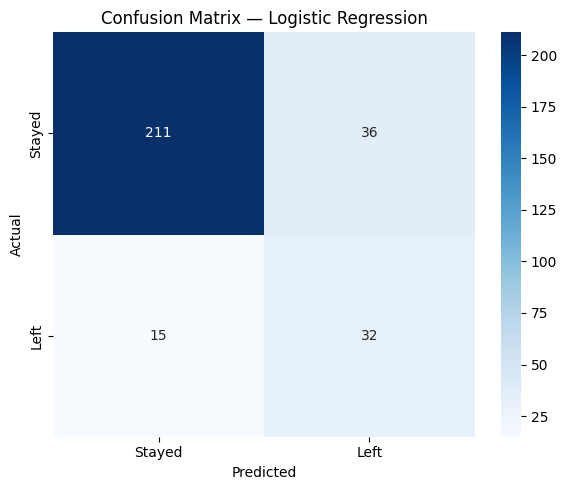

In [120]:

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
ax.set_title('Confusion Matrix — Logistic Regression')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('plot_confusion_matrix.png')
plt.show()

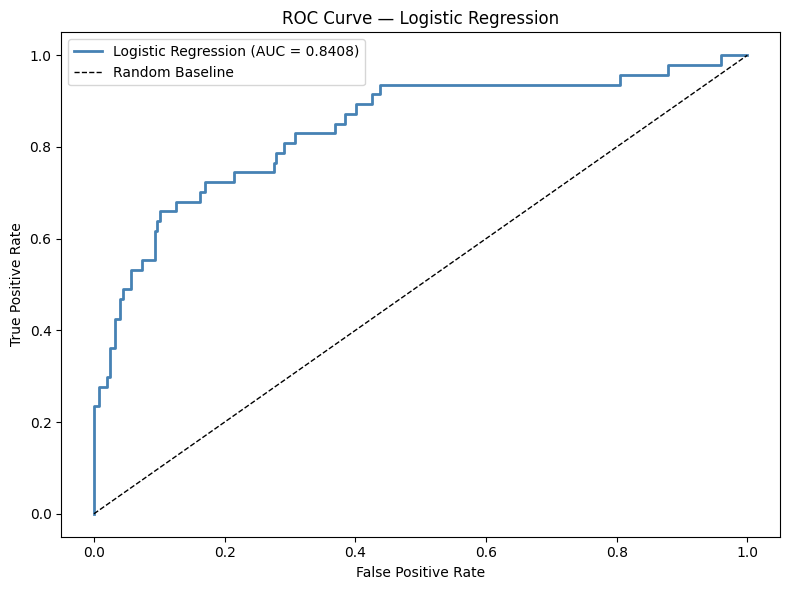

In [121]:
# --- ROC Curve ---
plt.figure(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('plot_roc_curve.png')
plt.show()

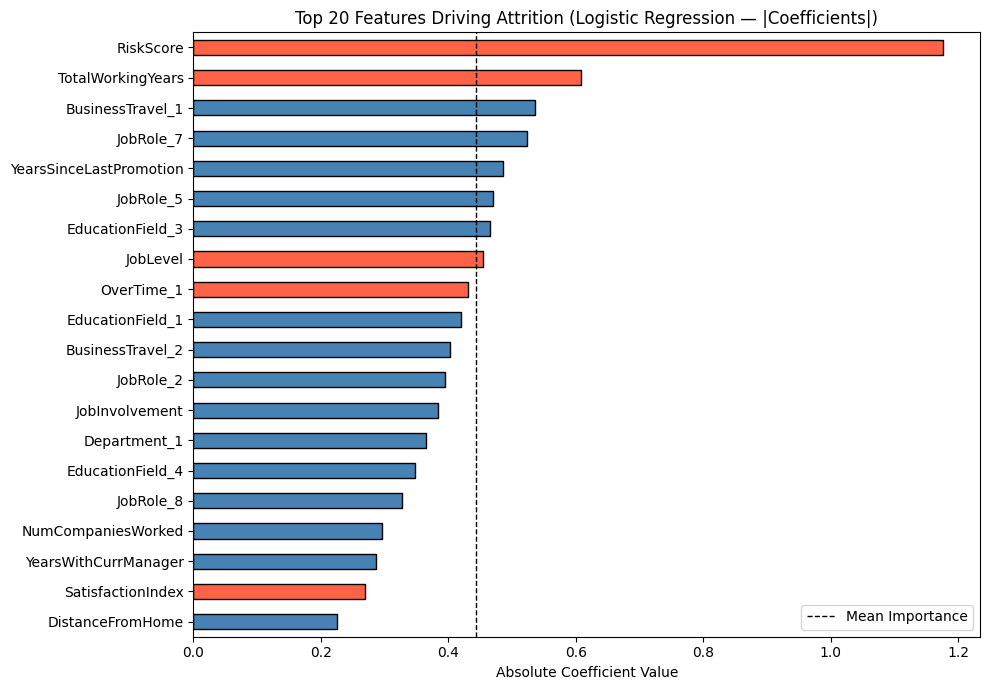


Top 10 most important features:
RiskScore                  1.175678
TotalWorkingYears          0.608970
BusinessTravel_1           0.535782
JobRole_7                  0.523736
YearsSinceLastPromotion    0.485575
JobRole_5                  0.470224
EducationField_3           0.465657
JobLevel                   0.454747
OverTime_1                 0.430581
EducationField_1           0.419134
dtype: float64


In [122]:
# --- Feature Importance via Coefficients ---
feat_imp = pd.Series(np.abs(lr.coef_[0]), index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
colors = ['tomato' if feat in
          ['OverTime_1', 'RiskScore', 'BurnoutFlag', 'SatisfactionIndex',
           'MonthlyIncome', 'Age', 'TotalWorkingYears', 'JobLevel',
           'StockOptionLevel']
          else 'steelblue' for feat in feat_imp.index]

feat_imp.plot(kind='barh', color=colors, edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 20 Features Driving Attrition (Logistic Regression — |Coefficients|)')
plt.xlabel('Absolute Coefficient Value')
plt.axvline(x=feat_imp.mean(), color='black', linestyle='--',
            linewidth=1, label='Mean Importance')
plt.legend()
plt.tight_layout()
plt.savefig('plot_feature_importance.png')
plt.show()

print("\nTop 10 most important features:")
print(feat_imp.head(10))



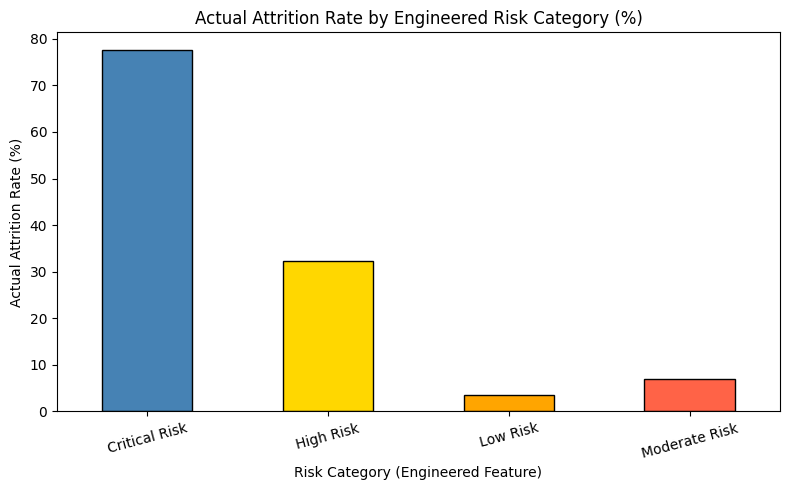

In [123]:
# --- Risk Category Validation ---
df_full = pd.read_csv('04_Data_cleaned_after_FE.csv')
df_full['Attrition_Binary'] = df_full['Attrition'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 5))
risk_validation = df_full.groupby('RiskCategory')['Attrition_Binary'].mean() * 100
risk_validation.plot(kind='bar',
                     color=['steelblue', 'gold', 'orange', 'tomato'],
                     edgecolor='black')
plt.title('Actual Attrition Rate by Engineered Risk Category (%)')
plt.xlabel('Risk Category (Engineered Feature)')
plt.ylabel('Actual Attrition Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot_risk_validation.png')
plt.show()

In [126]:

df_pbi = pd.read_csv('04_Data_cleaned_after_FE.csv')
df_pbi['Attrition_Binary'] = df_pbi['Attrition'].map({'Yes': 1, 'No': 0})

# Scale full dataset and get predictions
X_full_sc = scaler.transform(X)
df_pbi['Attrition_Probability_%'] = (lr.predict_proba(X_full_sc)[:, 1] * 100).round(2)
df_pbi['Predicted_Attrition'] = (lr.predict_proba(X_full_sc)[:, 1] >= 0.20).astype(int)

df_pbi['ML_Risk_Level'] = pd.cut(
    df_pbi['Attrition_Probability_%'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low', 'Moderate', 'High', 'Critical']
)

# Model performance summary table (for Power BI model page)
model_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC-ROC', 'CV AUC', 'Precision (Left)', 
               'Recall (Left)', 'F1-Score (Left)', 'Threshold Used'],
    'Value':  ['83%', '0.8408', '0.8460', '47%', '68%', '0.56', '0.20']
})

df_pbi.to_csv('05_Data_after_modelling.csv', index=False)
model_metrics.to_csv('06_HR_Model_Metrics.csv', index=False)
print("Exported 05_Data_after_modelling.csv —", df_pbi.shape)
print("Exported 06_HR_Model_Metrics.csv")
print("\nML Risk Level distribution:")
print(df_pbi['ML_Risk_Level'].value_counts().sort_index())

Exported HR_Attrition_PowerBI.csv — (1470, 42)
Exported HR_Model_Metrics.csv

ML Risk Level distribution:
ML_Risk_Level
Low         1161
Moderate     158
High          92
Critical      58
Name: count, dtype: int64
